# IN3050/IN4050 Mandatory Assignment 2, 2025: Supervised Learning

## Introduction

### Rules

Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html , in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html 
We do not entirely prohibit the use of generative language models ("smart assistants" like ChatGPT, Llama, Claude or Copilot), but you must clearly acknowledge this at all times, following the UiO guidelines: https://www.uio.no/english/studies/resources/ai_student.html
Note also that you must fully understand _all_ the parts of you submissions, even if you got some help from a generative model. This will be tested during your peer review sessions (https://www.uio.no/studier/emner/matnat/ifi/IN3050/v25/Peer%20review/).
By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Friday, March 28, 2025, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

### What to deliver?

You are recommended to solve the exercise in a Jupyter notebook, but you might solve it in a regular Python script if you prefer.

#### Alternative 1
If you prefer not to use notebooks, you should deliver the code, your run results, and a PDF report where you answer all the questions and explain your work.

#### Alternative 2
If you choose Jupyter, you should deliver the notebook. You should answer all questions and explain what you are doing in Markdown. Still, the code should be properly commented. The notebook should contain results of your runs. In addition, you should make a PDF of your solution which shows the results of the runs. (If you can't export: notebook -> latex -> pdf on your own machine, you may do this on the IFI linux machines.)

Here is a list of *absolutely necessary* (but not sufficient) conditions to get the assignment marked as passed:

- You must deliver your code (Python script or Jupyter notebook) you used to solve the assignment.
- The code used for making the output and plots must be included in the assignment. 
- You must include example runs that clearly shows how to run all implemented functions and methods.
- All the code (in notebook cells or python main-blocks) must be runnable. If you have unfinished code that crashes, please comment it out and document what you think causes it to crash. 
- You must also deliver a PDF of the code, outputs, comments and plots as explained above.

Your report/notebook should contain your name and username.

Deliver one single compressed folder (.zip, .tgz or .tar.gz) which contains your complete solution.

Important: if you weren’t able to finish the assignment, use the PDF report/Markdown to elaborate on what you’ve tried and what problems you encountered. Students who have made an effort and attempted all parts of the assignment will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

### Goals of the assignment
The goal of this assignment is to get a better understanding of supervised learning with gradient descent. It will, in particular, consider the similarities and differences between linear classifiers and multi-layer feed forward neural networks (multi-layer perceptrons, MLP) and the differences and similarities between binary and multi-class classification. 

### Tools
The aim of the exercises is to give you a look inside the learning algorithms. You may freely use code from the weekly exercises and the published solutions. You should not use machine learning libraries like Scikit-Learn or PyTorch, because the point of this assignment is for you to implement things from scratch. You, however, are encouraged to use tools like NumPy, Pandas and MatPlotLib, which are not ML-specific.

The given precode uses NumPy. You are recommended to use NumPy since it results in more compact code, but feel free to use pure Python if you prefer. 

If anything is unclear, do not hesitate to ask. Also, if you think some assumptions are missing, make your own and explain them!

## Imports

In [1]:
import sklearn # This is only to generate a dataset
import matplotlib
import numpy as np
from tqdm import tqdm
from typing import Literal
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from matplotlib.ticker import FuncFormatter
matplotlib.rcParams.update({'font.size': 14, 'figure.figsize': (16, 10)})

## Datasets

We start by making a synthetic dataset of 5000 instances and ten classes, with 500 instances in each class. (See https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html regarding how the data are generated.) We choose to use a synthetic dataset---and not a set of natural occuring data---because we are mostly interested in properties of the various learning algorithms, in particular the differences between linear classifiers and multi-layer neural networks together with the difference between binary and multi-class data. In addition, we would like a dataset with instances represented with only two numerical features, so that it is easy to visualize the data. It would be rather difficult (although not impossible) to find a real-world dataset of the same nature. Anyway, you surely can use the code in this assignment for training machine learning models on real-world datasets.

When we are doing experiments in supervised learning, and the data are not already split into training and test sets, we should start by splitting the data. Sometimes there are natural ways to split the data, say training, on data from one year and testing on data from a later year, but if that is not the case, we should shuffle the data randomly before splitting. (OK, that is not necessary with this particular synthetic data set, since it is already shuffled by default by Scikit-Learn, but that will not be the case with real-world data) We should split the data so that we keep the alignment between X (features) and t (class labels), which may be achieved by shuffling the indices. We split into 60% for training, 20% for validation, and 20% for final testing. The set for final testing *must not be used* till the end of the assignment in part 3.

We fix the seed both for data set generation and for shuffling, so that we work on the same datasets when we rerun the experiments. This is done by the `random_state` argument and the `rng = np.random.RandomState(424242)`.

In [2]:
# Generating the dataset
from sklearn.datasets import make_blobs
X, t_multi = make_blobs(n_samples=[500, 500, 500, 500, 500, 500, 500, 500, 500, 500], centers=[[0,1],[4,2],[8,1],[2,0],[6,0],[3,-3],[4,-2],[0,5],[0,4],[-2,-2]], 
                  n_features=2, random_state=424242, cluster_std=[1.0, 2.0, 1.0, 0.5, 0.5, 3.0, 1.0, 0.5, 2.5, 2.5])

In [3]:
# Shuffling the dataset
indices = np.arange(X.shape[0])
rng = np.random.RandomState(424242)
rng.shuffle(indices)
indices[:10]

array([3560, 4674,   49, 1257,  661, 3066, 3834, 4792,  570, 3855])

In [4]:
# Splitting into train, dev and test
X_train = X[indices[:3000],:]
X_val = X[indices[3000:4000],:]
X_test = X[indices[4000:],:]
t_multi_train = t_multi[indices[:3000]]
t_multi_val = t_multi[indices[3000:4000]]
t_multi_test = t_multi[indices[4000:]]

Next, we will  make a second dataset with only two classes by merging the existing labels in (X,t), so that `0-5` become the new `0` and `6-9` become the new `1`. Let's call the new set (X, t2). This will be a binary set.
We now have two datasets:

- Binary set: `(X, t2)`
- Multi-class set: `(X, t_multi)`

In [5]:
t2_train = t_multi_train >= 6
t2_train = t2_train.astype("int")
t2_val = (t_multi_val >= 6).astype("int")
t2_test = (t_multi_test >= 6).astype("int")

We can plot the two traning sets.

Text(0.5, 1.0, 'Multi-class set')

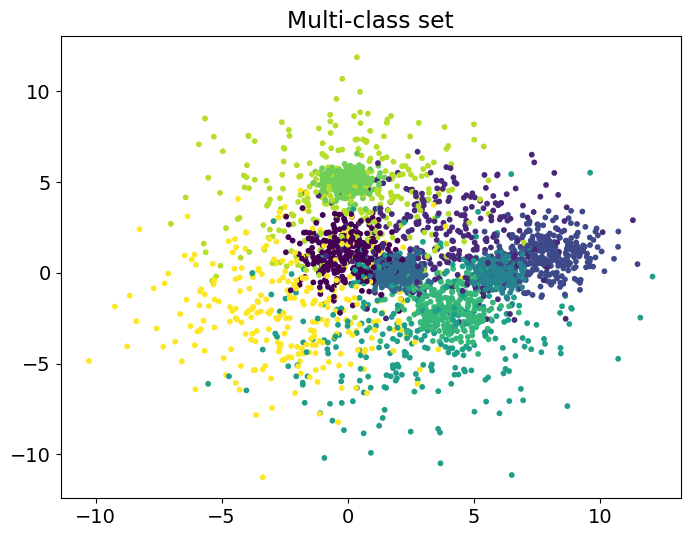

In [6]:
plt.figure(figsize=(8,6)) # You may adjust the size
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_multi_train, s=10.0)
plt.title("Multi-class set")

Text(0.5, 1.0, 'Binary set')

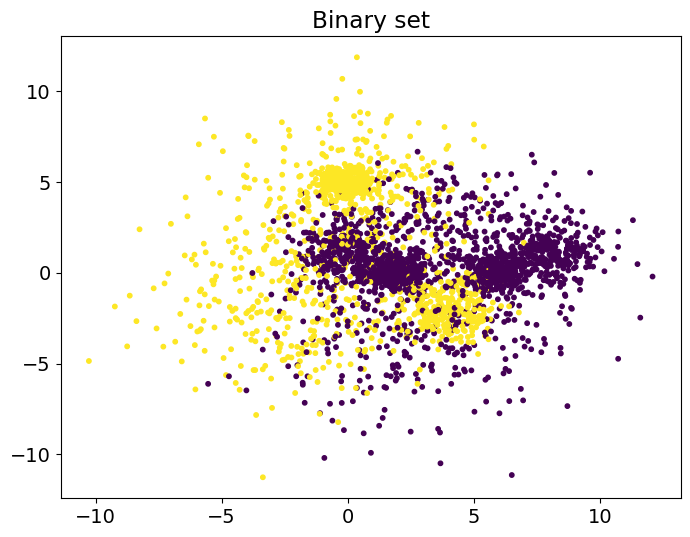

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=t2_train, s=10.0)
plt.title("Binary set")

# Part 1: Linear classifiers
### Linear regression

We see that even the binary set (X, t2) is far from linearly separable, and we will explore how various classifiers are able to handle this. We start with linear regression with the Mean Squared Error (MSE) loss, although it is not the most widely used approach for classification tasks: but we are interested. You may make your own implementation from scratch or start with the solution to the weekly exercise set 6. We include it here with a little added flexibility.

In [8]:
def add_bias(X, bias):
    """X is a NxM matrix: N datapoints, M features
    bias is a bias term, -1 or 1, or any other scalar. Use 0 for no bias
    Return a Nx(M+1) matrix with added bias in position zero
    """
    N = X.shape[0]
    biases = np.ones((N, 1)) * bias # Make a N*1 matrix of biases
    # Concatenate the column of biases in front of the columns of X.
    return np.concatenate((biases, X), axis  = 1) 

In [9]:
class NumpyClassifier():
    """Common methods to all Numpy classifiers --- if any"""
    def fit():
        raise NotImplementedError("Inheriting classes must implement this method")
    def predict():
        raise NotImplementedError("Inheriting classes must implement this method")

In [10]:
class NumpyLinRegClass(NumpyClassifier):
    def __init__(self, bias=-1):
        self.bias=bias
    
    def fit(self, X_train, t_train, lr = 0.1, epochs=10):
        """X_train is a NxM matrix, N data points, M features
        t_train is avector of length N,
        the target class values for the training data
        lr is our learning rate
        """
        
        if self.bias:
            X_train = add_bias(X_train, self.bias)
            
        (N, M) = X_train.shape
        
        self.weights = weights = np.zeros(M)
        
        for epoch in range(epochs):
            # print("Epoch", epoch)
            weights -= lr / N *  X_train.T @ (X_train @ weights - t_train)      
    
    def predict(self, X, threshold=0.5):
        """X is a KxM matrix for some K>=1
        predict the value for each point in X"""
        if self.bias:
            X = add_bias(X, self.bias)
        ys = X @ self.weights
        return ys > threshold

We can train and test a first classifier (on the binary dataset).

In [11]:
def accuracy(predicted, gold):
    return np.mean(predicted == gold)

In [12]:
cl = NumpyLinRegClass()
cl.fit(X_train, t2_train, epochs=10)
accuracy(cl.predict(X_val), t2_val)

0.638

The following is a small procedure which plots the data set together with the decision boundaries. 
You may modify the colors and the rest of the graphics as you like.
The procedure will also work for multi-class classifiers

In [13]:
def plot_decision_regions(X, t, clf=[], size=(8,6)):
    """Plot the data set (X,t) together with the decision boundary of the classifier clf"""
    # The region of the plane to consider determined by X
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Make a prediction of the whole region
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Classify each meshpoint.
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=size) # You may adjust this

    # Put the result into a color plot
    plt.contourf(xx, yy, Z, alpha=0.2, cmap = 'tab10')

    plt.scatter(X[:,0], X[:,1], c=t, s=10.0, cmap='tab10')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Decision regions")
    plt.xlabel("x0")
    plt.ylabel("x1")

#    plt.show()

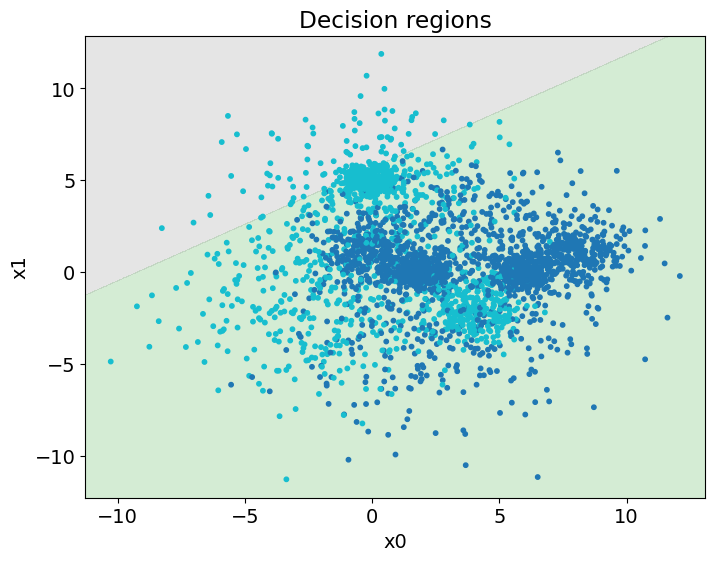

In [14]:
plot_decision_regions(X_train, t2_train, cl)

### Task: Tuning

The result is far from impressive. 
Remember that a classifier which always chooses the majority class will have an accuracy of 0.6 on this data set.

Your task is to try various settings for the two training hyper-parameters, learning rate and the number of epochs, to get the best accuracy on the validation set. 

Report how the accuracy varies with the hyper-parameter settings. It it not sufficient to give the final hyperparameters. You must also show how you found then and results for alternative values you tried aout.

When you are satisfied with the result, you may plot the decision boundaries, as above.

In [15]:
def grid_search(X_train, t_train, X_val, t_val, cl: NumpyClassifier, grid_params: dict, func_params: dict = {}) -> np.ndarray:
    '''
    Performs a grid search over the learning rates and epochs.
    
    Parameters
    ----------
    X_train : np.ndarray
        The training data.
    t_train : np.ndarray
        The training targets.
    X_val : np.ndarray
        The validation data.
    t_val : np.ndarray
        The validation targets.
    cl : NumpyLinRegClass
        The classifier.
    grid_params : dict
        A dictionary of hyperparameters with the key being the hyperparameter name and the value being the array of hyperparameters. The first parameter will be the x-axis and the second parameter will be the y-axis.
    func_params : dict [optional]
        A dictionary of static parameters to pass to the `cl.fit()` function, other than `X_train` and `t_train`
        
    Returns
    -------
    accuracies : np.ndarray
        A 2D array of validation accuracies.
    '''
    param_name1, param_name2 = grid_params.keys()
    param_array1, param_array2 = grid_params.values()
    nx = len(param_array1)
    ny = len(param_array2)
    accuracies = np.zeros((ny, nx))
    
    # Function to evaluate a single set of hyperparameters
    def evaluate_hyperparams(param1, param2):
        # Create a fresh classifier instance to avoid state interference
        clf = type(cl)()
        if hasattr(cl, 'bias'):
            clf.bias = cl.bias
        
        # Parameter dictionaries for passing keyword arguments
        func_kwarg_1 = {param_name1: param1}
        func_kwarg_2 = {param_name2: param2}
        # Train and evaluate
        clf.fit(X_train, t_train, **func_kwarg_1, **func_kwarg_2, **func_params)
        return accuracy(clf.predict(X_val), t_val)

    # Run grid search with outer loop sequential and inner loop parallel
    for j, param1 in enumerate(tqdm(param_array1, desc=param_name1)):
        results = Parallel(n_jobs=-1)(delayed(evaluate_hyperparams)(param1, param2) for param2 in param_array2)
        
        for i, acc in enumerate(results):
            # Fill matrix from the bottom up, to match y-axis increasing upwards
            accuracies[i, j] = acc
            
    return accuracies

In [16]:
def optimal_hyperparameters(accuracies, x_array, y_array):
    '''
    Find the best hyperparameters based on the validation accuracy.
    
    Parameters
    ----------
    accuracies : np.ndarray
        A 2D array of validation accuracies.
    x_array : np.ndarray
        An array of the first hyperparameter changing along the rows of `accuracies`.
    y_array : np.ndarray
        An array of the second hyperparameter changing along the columns of `accuracies`.
        
    Returns
    -------
    best_accuracy : float
        The best validation accuracy.
   best_x : np.ndarray
        The best hyperparameter(s) value for the first hyperparameter.
    best_y : np.ndarray
        The best hyperparameter(s) value for the second hyperparameter.
    '''
    assert accuracies.shape == (len(y_array), len(x_array)), f'Accuracies shape {accuracies.shape} does not match the grid shape {len(y_array), len(x_array)}. Maybe try the other way around?'
    
    best_accuracy = np.max(accuracies)
    best_parameter_idx = np.where(accuracies == best_accuracy)
    best_x = x_array[best_parameter_idx[1]]
    best_y = y_array[best_parameter_idx[0]]
    
    return best_accuracy, best_x, best_y

In [17]:
def sort_optimal_hyperparameters(primary_array, secondary_array, descending=False):
    '''
    Sort the optimal hyperparameters arrays based on the sorted index of the first array.
    
    Parameters
    ----------
    primary_array : np.ndarray
        The first optimal hyperparameter array.
    secondary_array : np.ndarray
        The second optimal hyperparameter array.
    descending : bool [optional]
        Whether to sort the arrays in descending order. Default is False.
    '''
    # Get the indices that would sort the primary array
    sort_indices = np.argsort(primary_array)
    # If descending is True, reverse the order
    if descending:
        sort_indices = sort_indices[::-1]
    # Sort both arrays using the same indices
    sorted_primary = primary_array[sort_indices]
    sorted_secondary = secondary_array[sort_indices]
    return sorted_primary, sorted_secondary
    

In [18]:
x_array = np.array([1, 0])
y_array = np.array([0, 1, 2])

acc = np.array([[1,     1], 
                [0.7, 0.8],
                [0.9,   3]])
best_accuracy, best_x, best_y = optimal_hyperparameters(acc, x_array, y_array)

print(f'Best accuracy: {best_accuracy}')
print(f'Best x: {best_x}')
print(f'Best y: {best_y}')

print(sort_optimal_hyperparameters(best_x, best_y))
print(sort_optimal_hyperparameters(best_x, best_y, descending=True))

print(sort_optimal_hyperparameters(best_y, best_x))
print(sort_optimal_hyperparameters(best_y, best_x, descending=True))

Best accuracy: 3.0
Best x: [0]
Best y: [2]
(array([0]), array([2]))
(array([0]), array([2]))
(array([2]), array([0]))
(array([2]), array([0]))


In [ ]:
def plot_grid_search(accuracies: np.ndarray, x_array: np.ndarray, y_array: np.ndarray, labels: tuple[str, str], logx: bool = False, logy: bool = False) -> plt.Figure:
    '''
    Plots the validation accuracy for different two hyperparameters.
    
    Parameters
    ----------
    accuracies : np.ndarray
        A 2D array of validation accuracies.
    x_array : np.ndarray
        An array of the first hyperparameter. 
    y_array : np.ndarray
        An array of the second hyperparameter.
    labels : tuple[str, str]
        The labels for the x and y axis.
        
    Returns
    -------
    fig : plt.Figure
        The figure
    '''
    def log10(array: np.ndarray) -> np.ndarray:
        return np.log10(array)
    
    def identity(array: np.ndarray) -> np.ndarray:
        return array
    
    if logx:
        scale_x = log10
    else:
        scale_x = identity
    if logy:
        scale_y = log10
    else:
        scale_y = identity
        
    
    XX, YY = np.meshgrid(scale_x(x_array), scale_y(y_array))
    
    # Contour plot
    contour = plt.contourf(XX, YY, accuracies, levels=len(np.unique(accuracies).ravel()), cmap='viridis')
    plt.colorbar(contour, label='Validation Accuracy', format=FuncFormatter('{:.2%}'.format))
    
    # Contour lines 
    contour_lines = plt.contour(XX, YY, accuracies, 10, colors='white', linewidths=0.75, alpha=0.9)
    plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%.3f') 
    
    # Finding the best hyperparameters
    best_accuracy, best_param1, best_param2 = optimal_hyperparameters(accuracies, x_array, y_array)
    
    # Marking the best hyperparameters
    x = best_param1[0]
    y = best_param2[0]
    parameter_str = ''.join(f'\n({labels[0]}={x:.3g}, {labels[1]}={y:.3g})' for x, y in zip(best_param1, best_param2))
    
    # Plotting the first set of best hyperparameters with labels
    plt.scatter(scale_x(x), scale_y(y), color='hotpink', s=200, marker='*', 
            edgecolors='white', linewidths=1.5, zorder=5,
            label=f'Highest: {best_accuracy:.2%}' + parameter_str)
    
    # Plotting the rest of the best hyperparameters
    for param1, param2, in zip(best_param1, best_param2):
        plt.scatter(scale_x(param1), scale_y(param2), color='hotpink', s=200, marker='*', 
                edgecolors='white', linewidths=1.5, zorder=5)

    # Labels
    plt.xlabel(labels[0] + r" [log$_{10}$]"*logx)
    plt.ylabel(labels[1] + r" [log$_{10}$]"*logy)
    
    # y-tick formatting
    if logx:
        plt.xticks([np.log10(param1) for param1 in x_array], 
                   [f'{param1:.1e}' for param1 in x_array], rotation=45)
    if logy:    
        plt.yticks([np.log10(param2) for param2 in y_array], 
                [f'{param2:.1e}' for param2 in y_array])
        
    plt.legend()
    plt.grid(alpha=0.2)
    
    fig = plt.gcf()
    
    return fig

In [20]:
start = 10
stop = 400
step = 10
n_x = (stop - start) // step
epochs = np.arange(start, stop, step, dtype=int)

n_y = 20
learning_rates = np.logspace(-3, -1, n_y)

grid_params = {'epochs': epochs, 'lr': learning_rates}

cl = NumpyLinRegClass()
accuracies = grid_search(X_train, t2_train, X_val, t2_val, cl, grid_params)

epochs: 100%|██████████| 39/39 [00:02<00:00, 15.07it/s]


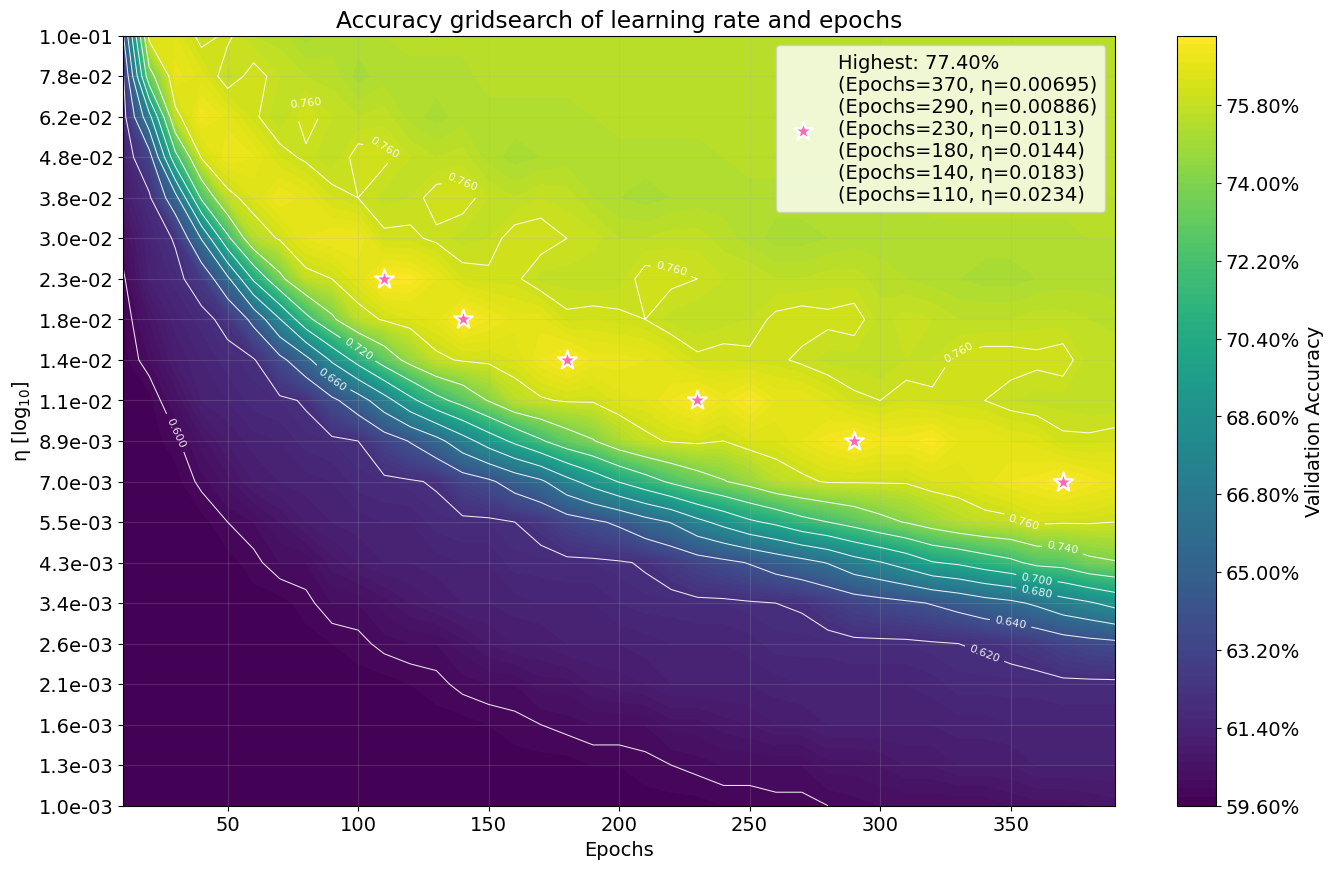

In [21]:
fig = plot_grid_search(accuracies, epochs, learning_rates, labels=('Epochs', 'η'), logy=True)
plt.title('Accuracy gridsearch of learning rate and epochs')
plt.show()

Best hyperparameters: learning rate = 0.023357, epochs = 110
Best validation accuracy: 0.7740


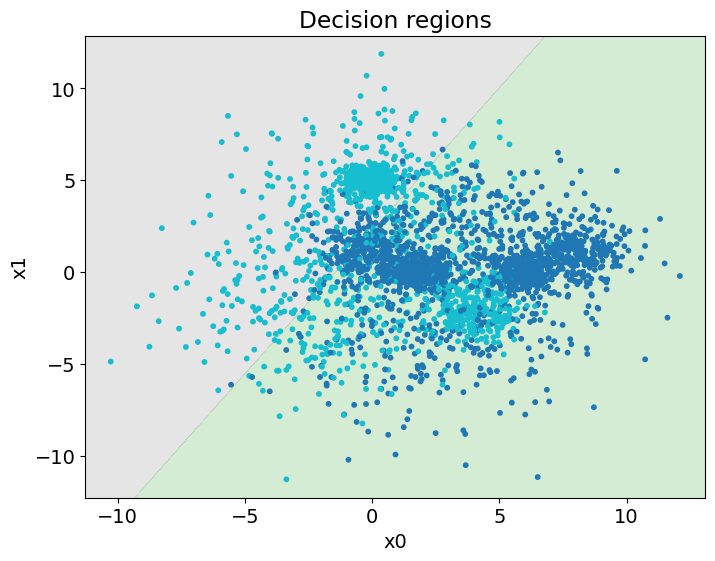

In [22]:
best_accuracy, best_epochs, best_lrs = optimal_hyperparameters(accuracies, epochs, learning_rates)

best_epochs, best_lrs = sort_optimal_hyperparameters(best_epochs, best_lrs)

best_epoch = best_epochs[0]
best_lr = best_lrs[0]
# Train the best model
best_cl = NumpyLinRegClass()
best_cl.fit(X_train, t2_train, lr=best_lr, epochs=int(best_epoch))
val_accuracy = accuracy(best_cl.predict(X_val), t2_val)

print(f"Best hyperparameters: learning rate = {best_lr:.6f}, epochs = {best_epoch}")
print(f"Best validation accuracy: {val_accuracy:.4f}")

# Plot decision regions with the best model
plot_decision_regions(X_train, t2_train, best_cl)

#### Conclusion
- Using a grid search, we find the best hyperparameters for the linear regression classifier. 
- We get an accuracy of 0.7740, which is as good as we can expect for a linear classifier on this dataset. 

### Task: Scaling

We have seen in the lectures that scaling the data may improve training speed and sometimes the performance. 

- Implement the standard scaler (normalizer); you can also try other scaling techniques
- Scale the data
- Train the model on the scaled data
- Experiment with hyper-parameter settings and see whether you can speed  up or improve the training.
- Report final hyper-parameter settings and show how you found them.

In [23]:
def standard_scaler(X_train: np.ndarray, X_val: np.ndarray) -> np.ndarray:
    '''
    Standard scaling of training and validation data with respect to the training data.
    
    Parameters:
    X_train: np.ndarray
        Training data.
    X_val: np.ndarray
        Validation data.
        
    Returns:
    X_train_scaled: np.ndarray
        Scaled training data.
    X_val_scaled: np.ndarray
        Scaled validation data.
    '''
    μ = np.mean(X_train, axis=0)
    σ = np.std(X_train, axis=0)
    
    X_train_scaled = (X_train - μ) / σ
    X_val_scaled   = (X_val   - μ) / σ
    
    return X_train_scaled, X_val_scaled

In [24]:
X_train_scaled, X_val_scaled = standard_scaler(X_train, X_val)

cl = NumpyLinRegClass()

accuracies_scaled = grid_search(X_train_scaled, t2_train, X_val_scaled, t2_val, cl, grid_params)

epochs: 100%|██████████| 39/39 [00:01<00:00, 24.02it/s]


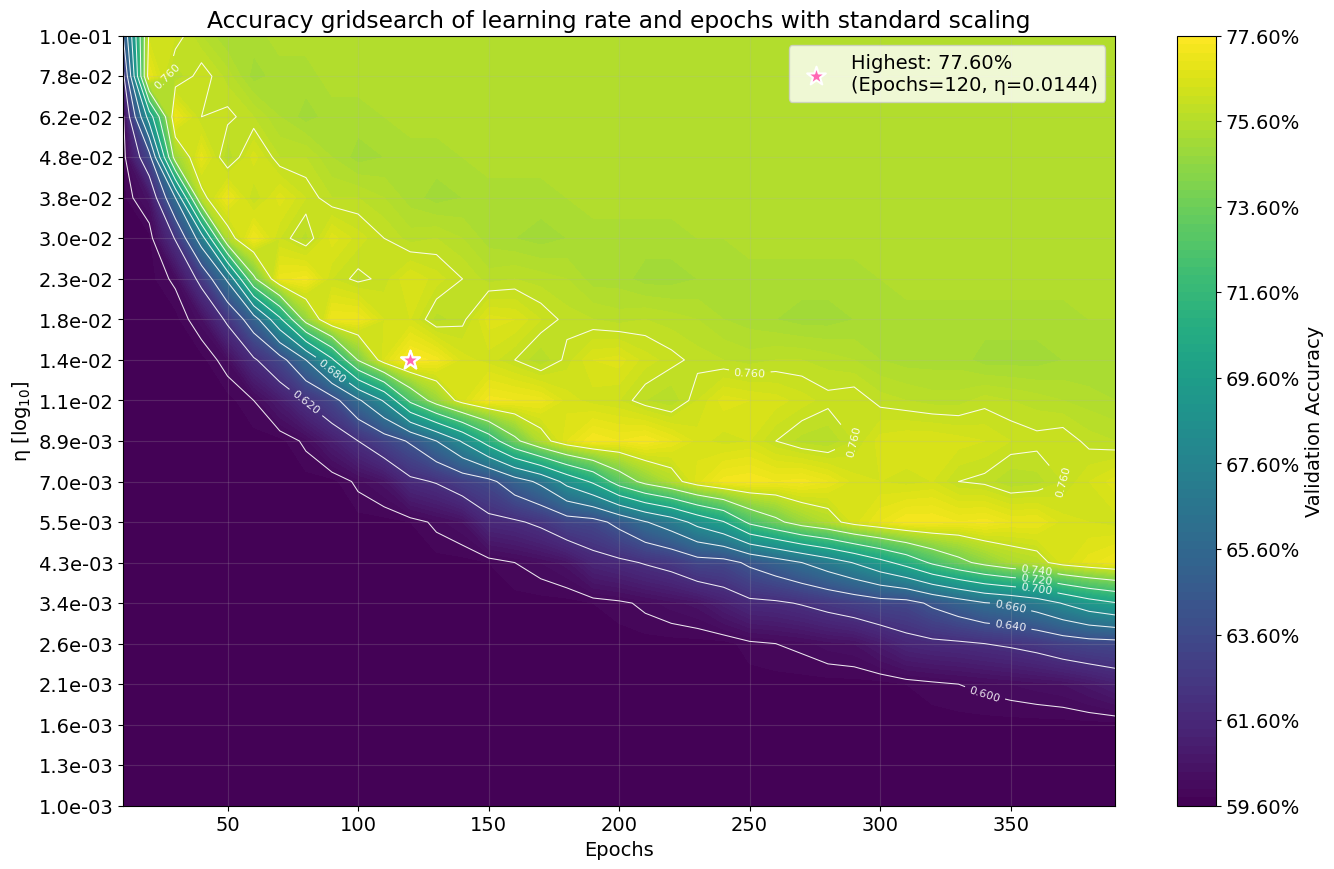

In [25]:
fig = plot_grid_search(accuracies_scaled, epochs, learning_rates, labels=('Epochs', 'η'), logy=True)
plt.title('Accuracy gridsearch of learning rate and epochs with standard scaling')
plt.show()

Best hyperparameters: learning rate = 0.014384, epochs = 120
Best validation accuracy: 0.7760


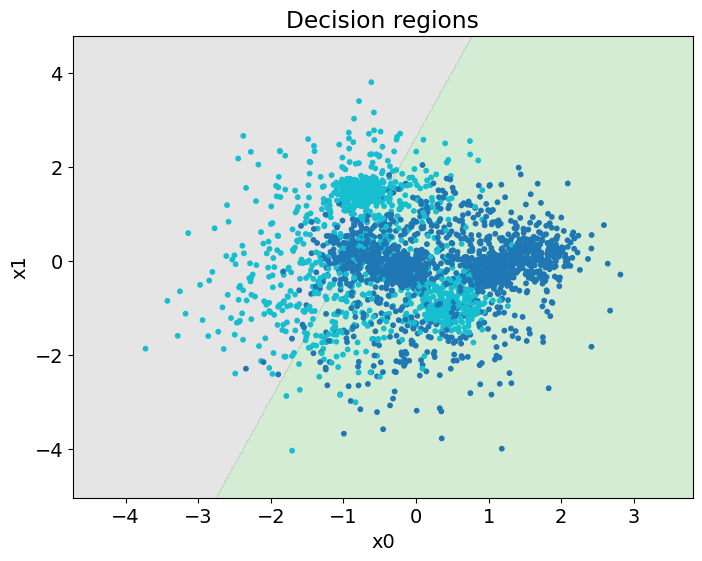

In [26]:
best_accuracy_scaled, best_epochs_scaled, best_lrs_scaled = optimal_hyperparameters(accuracies_scaled, epochs, learning_rates)

# Find the best hyperparameters with lowest number of epochs
best_epochs_scaled, best_lrs_scaled = sort_optimal_hyperparameters(best_epochs_scaled, best_lrs_scaled)

best_epoch_scaled = best_epochs_scaled[0]
best_lr_scaled = best_lrs_scaled[0]

# Train the best model
best_cl_scaled = NumpyLinRegClass()
best_cl_scaled.fit(X_train_scaled, t2_train, lr=best_lr_scaled, epochs=int(best_epoch_scaled))
val_accuracy = accuracy(best_cl_scaled.predict(X_val_scaled), t2_val)
print(f"Best hyperparameters: learning rate = {best_lr_scaled:.6f}, epochs = {best_epoch_scaled}")
print(f"Best validation accuracy: {val_accuracy:.4f}")

plot_decision_regions(X_train_scaled, t2_train, best_cl_scaled)

#### Conclusion
- Scaling the data gave a tiny bit better results.
- Scaling gave us a much larger larger range of hyperparameters giving good results. This is beneficial as reducing the number of epochs will increase the training speed.

## Logistic regression
a) You should now implement a logistic regression classifier similarly to the classifier based on linear regression.
You may use the code from the solution to weekly exercise set week06.

b) In addition to the method `predict()` which predicts a class for the data, include a method `predict_probabilities()` which predicts the probability of the data belonging to the positive class.

c) So far, we have not calculated the loss explicitly in the code. Extend the code to calculate the loss on the training set for each epoch and to store the losses such that the losses can be inspected after training. The prefered loss for logistic regression is binary cross-entropy, but you can also try mean squared error. The most important is that your implementation of the loss corresponds to your implementation of the gradient descent.
Also, calculate and store accuracies after each epoch.

d) In addition, extend the `fit()` method with optional arguments for a validation set (X_val, t_val). If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch. 

e) The training runs for a number of epochs. We cannot know beforehand for how many epochs it is reasonable to run the training. One possibility is to run the training until the learning does not improve much. Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved with more than `tol` after `n_epochs_no_update` (to save compute and potentially avoid over-fitting). A possible default value for `n_epochs_no_update` is 2. Also, add an attribute to the classifier which tells us after fitting how many epochs it was trained for.

f) Train classifiers with various learning rates, and with varying values for `tol` for finding the optimal values. Also consider the effect of scaling the data.

g) After a succesful training, for your best model, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see. Are the curves monotone? Is this as expected?

In [27]:
class NumpyLogReg(NumpyClassifier):
    def __init__(self, bias=-1, seed=420):
        self.bias = bias
        self.seed = seed

    def fit(self, X_train, t_train, lr = 0.1, epochs=10, X_val=None, t_val=None, tol=1e-5, n_epochs_no_update=2, min_epochs=0):
        '''
        Fit the model to the data
        
        Parameters
        -----------
        X_train: np.ndarray
            Training data
        t_train: np.ndarray
            Training target values
        lr: float [opt] 
            Learning rate. Default is 0.1
        epochs: int [opt]
            Number of epochs. Default is 10
        X_val: np.ndarray [opt]
            Validation data
        t_val: np.ndarray [opt]
            Validation target values
        tol: float [opt]
            Tolerance for early stopping after reaching `n_epochs_no_update`. Default is 1e-5
        n_epochs_no_update: int [opt]
            Number of epochs which to check for improvement greater than `tol`. Default is 2
        min_epochs: int [opt]
            Minimum number of epochs to run before early stopping. Default is 0
        '''
        
        validation: bool = X_val is not None and t_val is not None
        
        if self.bias:
            X_train = add_bias(X_train, self.bias)
            if validation:
                X_val = add_bias(X_val, self.bias)
        
        (N, M) = X_train.shape
        
        
        np.random.seed(self.seed)
        self.weights = weights = np.random.rand(M)
        
        self.loss = []
        self.accuracy = []
        self.val_loss = []
        self.val_accuracy = []
        self.convergence_epoch = None
            
        for e in range(epochs):
            if e > min_epochs:
                loss_avg = self.loss[e-n_epochs_no_update]
                improvement = loss_avg - self.loss[-1]
                if improvement < tol:
                    # print(f'Converged after {e} epochs' )
                    # print(f'Params: lr={lr}, epochs={epochs}, tol={tol}, n_epochs_no_update={n_epochs_no_update}, min_epochs={min_epochs}')
                    self.convergence_epoch = e
                    break
            
            weights -= lr / N *  X_train.T @ (self.forward(X_train) - t_train) 
            self.loss.append(self.cross_entropy_loss(X_train, t_train))
            self.accuracy.append(accuracy(self.predict(X_train), t_train))
            
            
            if validation:   
                self.val_loss.append(self.cross_entropy_loss(X_val, t_val))
                self.val_accuracy.append(accuracy(self.predict(X_val), t_val))
                
        if self.convergence_epoch is None:
            self.convergence_epoch = epochs
        
    def logistic(self, x):
        return 1 / (1 + np.exp(-x))
    
    def forward(self, X):
        return self.logistic(X @ self.weights)
    
    def predict(self, X, threshold=0.5):
        is_dimensions_one_off = X.shape[1] == self.weights.shape[0] - 1
        if self.bias and is_dimensions_one_off:
            X = add_bias(X, self.bias)
            
        ys = self.forward(X)
        return ys > threshold
    
    def predict_probabilites(self, X):
        is_dimensions_one_off = X.shape[1] == self.weights.shape[0] - 1
        if self.bias and is_dimensions_one_off:
            X = add_bias(X, self.bias)
        return self.forward(X)
    
    def cross_entropy_loss(self, X_train, t_train):
        p = self.predict_probabilites(X_train)
        return -np.mean(t_train * np.log(p) + (1 - t_train) * np.log(1 - p))
    
    
def plot_loss(cl: NumpyLogReg, epoch) -> plt.Figure:
    '''
    Plots the loss of the classifier.
    '''
    plt.plot(cl.loss, label='Training Loss', color='darkblue')
    plt.plot(cl.val_loss, label='Validation Loss', color='aqua', linestyle='--')
    lines_loss, labels_loss = plt.gca().get_legend_handles_labels()
    plt.ylabel('Cross-Entropy Loss', color='blue')
    plt.yticks(color='blue')
    plt.xlabel('Epochs')

    plt.twinx()

    plt.plot(cl.accuracy, label='Training Accuracy', color='darkgreen')
    plt.plot(cl.val_accuracy, label='Validation Accuracy', color='lime', linestyle='--')
    lines_acc, labels_acc = plt.gca().get_legend_handles_labels()
    plt.ylabel('Accuracy', color='green')
    plt.yticks(color='green')
    percentage_formatter = lambda x, _: f'{x:.1%}'
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(percentage_formatter))

    plt.title(f'Training and Validation Loss and accuracy converging at epoch {cl.convergence_epoch}/{epoch}')
    plt.legend(lines_loss + lines_acc, labels_loss + labels_acc)
    
    fig = plt.gcf()
    return fig
    

In [40]:
from dataclasses import dataclass

@dataclass
class Parameters:
    X_train: np.ndarray = None
    t_train: np.ndarray = None
    X_val: np.ndarray = None
    t_val: np.ndarray = None
    cl: NumpyLogReg = None
    grid_params: dict = None
    func_params: dict = None
    
@dataclass
class Results:
    accuracies: np.ndarray = None
    best_accuracy: float = None
    grid_param_1: np.ndarray = None
    grid_param_2: np.ndarray = None
    best_param_1: np.ndarray = None
    best_param_2: np.ndarray = None

In [65]:
cl_logreg = NumpyLogReg()
epoch = 2000
n_epochs_no_update = 10
min_epochs = 100

lr_start = -4
lr_stop = -1
n_lr = (lr_stop - lr_start + 1) * 4
learning_rates_logreg = np.logspace(lr_start, lr_stop, n_lr)

tol_start = -6
tol_stop = -1
n_tol = (tol_stop - tol_start + 1) * 4
tolerances = np.logspace(tol_start, tol_stop, n_tol)

# Dynamic variables that will be iterated over in grid search
grid_params = {'tol': tolerances, 'lr': learning_rates_logreg}
# Static variables that will be passed to the fit function
func_params = {'epochs': epoch, 'X_val': X_val, 't_val': t2_val, 'n_epochs_no_update': n_epochs_no_update, 'min_epochs': min_epochs}

accuracies_logreg = grid_search(X_train, t2_train, X_val, t2_val, cl_logreg, grid_params, func_params)

tol: 100%|██████████| 24/24 [00:10<00:00,  2.28it/s]


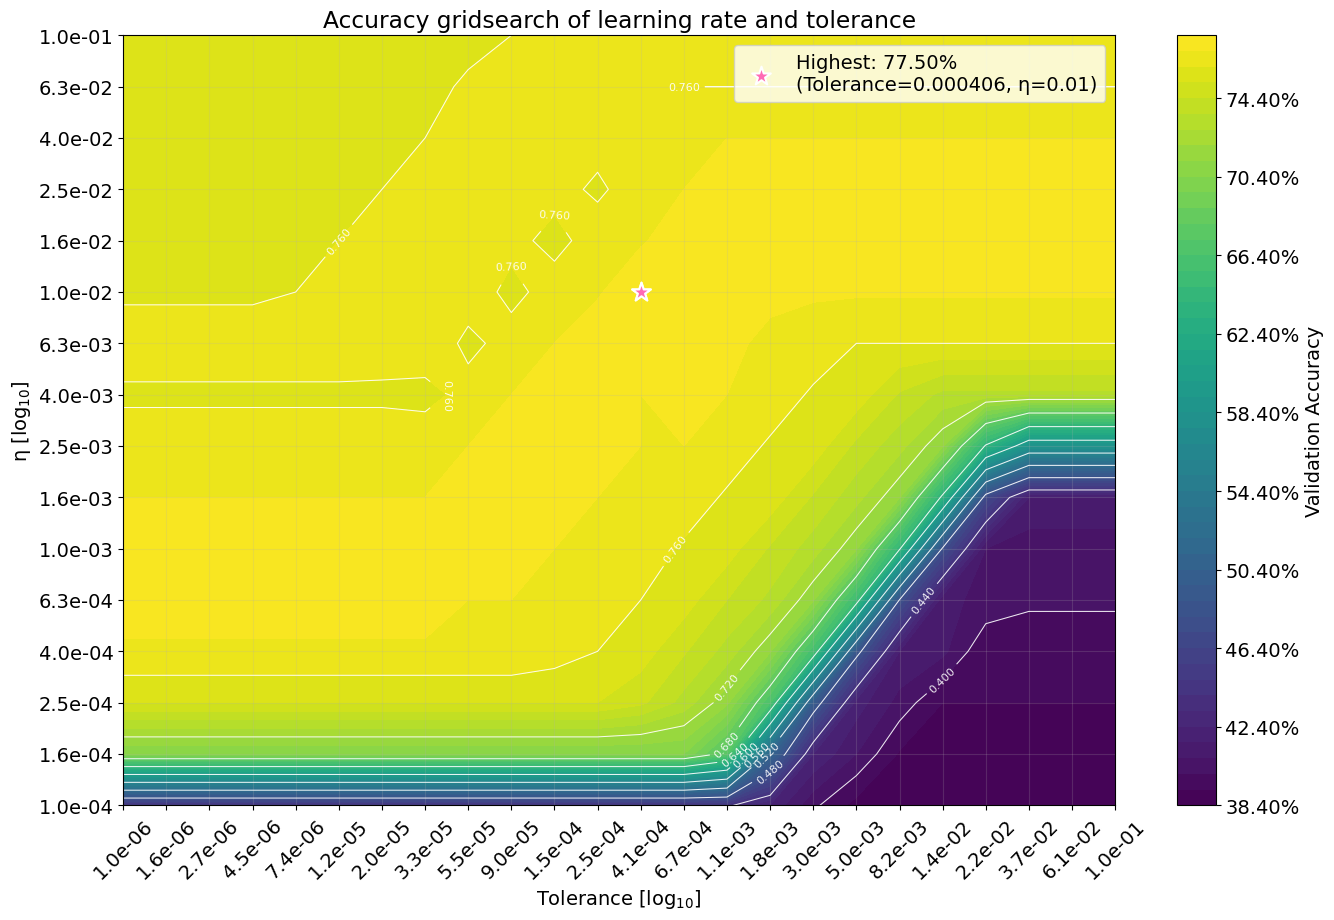

In [66]:
fig = plot_grid_search(accuracies_logreg, tolerances, learning_rates_logreg, labels=('Tolerance', 'η'), logx=True, logy=True)
plt.title('Accuracy gridsearch of learning rate and tolerance')
plt.show()

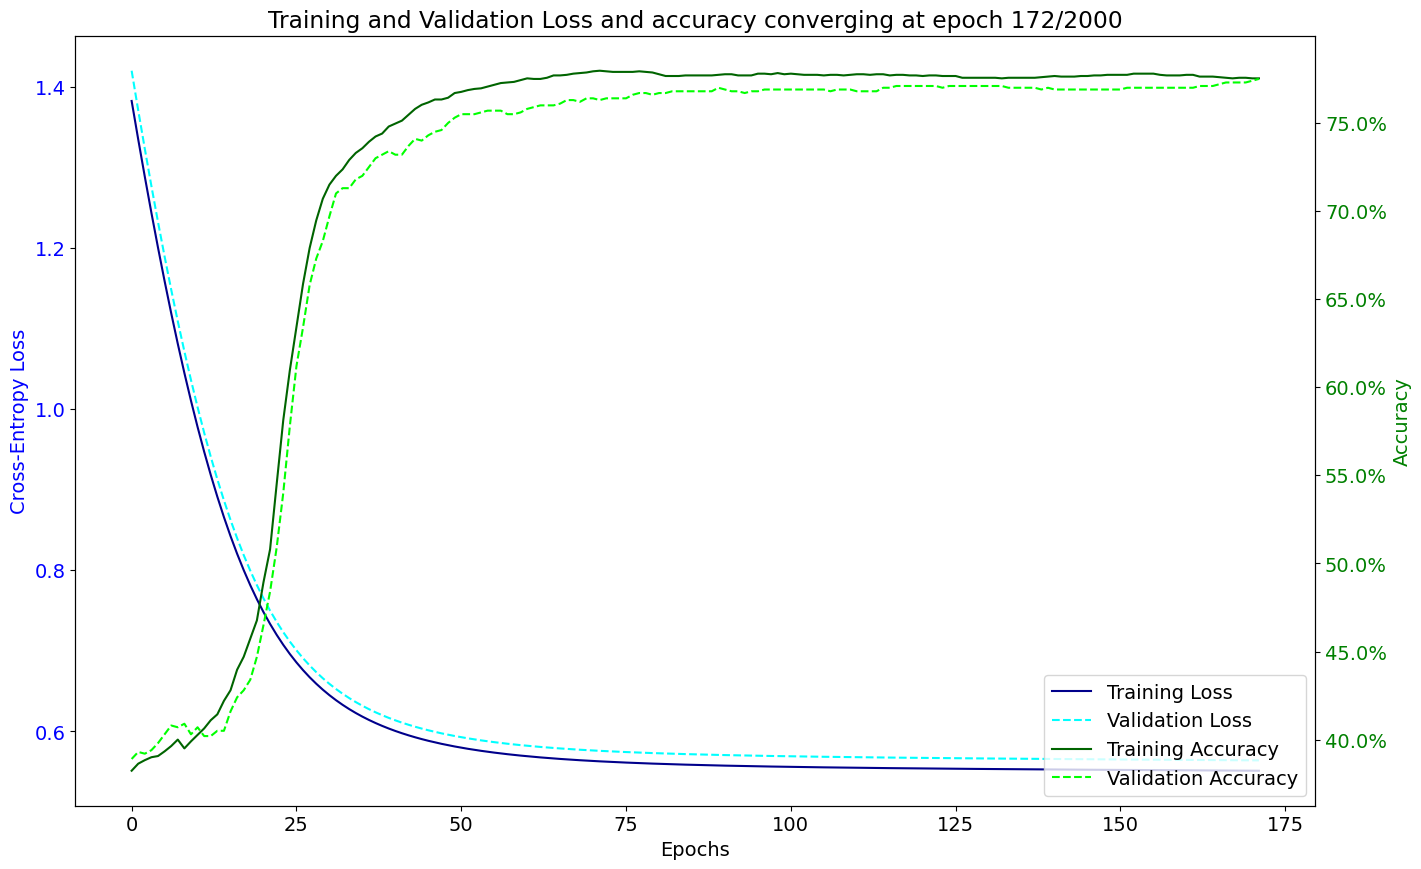

In [67]:
best_accuracy_logreg, best_tols_logreg, best_lrs_logreg = optimal_hyperparameters(accuracies_logreg, tolerances, learning_rates_logreg)

best_tols_logreg, best_lrs_logreg = sort_optimal_hyperparameters(best_tols_logreg, best_lrs_logreg, descending=True)

best_tol_logreg = best_tols_logreg[0]
best_lr_logreg = best_lrs_logreg[0]

# Train the best model
best_cl_logreg = NumpyLogReg()
best_cl_logreg.fit(X_train, t2_train, lr=best_lr_logreg, tol=best_tol_logreg, epochs=epoch, X_val=X_val, t_val=t2_val, n_epochs_no_update=n_epochs_no_update, min_epochs=min_epochs)

fig = plot_loss(best_cl_logreg, epoch)
plt.show()

In [68]:
cl_logreg_scaled = NumpyLogReg()
epoch = 2000
n_epochs_no_update = 10
min_epochs = 500

# lr_start = -4
# lr_stop = -1
# n_lr = (lr_stop - lr_start + 1) * 2
# learning_rates_logreg = np.logspace(lr_start, lr_stop, n_lr)

# tol_start = -8
# tol_stop = -2
# n_tol = (tol_stop - tol_start + 1) * 1
# tolerances = np.logspace(tol_start, tol_stop, n_tol)

# Dynamic variables that will be iterated over in grid search
grid_params = {'tol': tolerances, 'lr': learning_rates_logreg,}
# Static variables that will be passed to the fit function
func_params = {'epochs': epoch, 'X_val': X_val_scaled, 't_val': t2_val, 'n_epochs_no_update': n_epochs_no_update, 'min_epochs': min_epochs}

accuracies_logreg_scaled = grid_search(X_train_scaled, t2_train, X_val_scaled, t2_val, cl_logreg_scaled, grid_params, func_params)

tol: 100%|██████████| 24/24 [00:20<00:00,  1.19it/s]


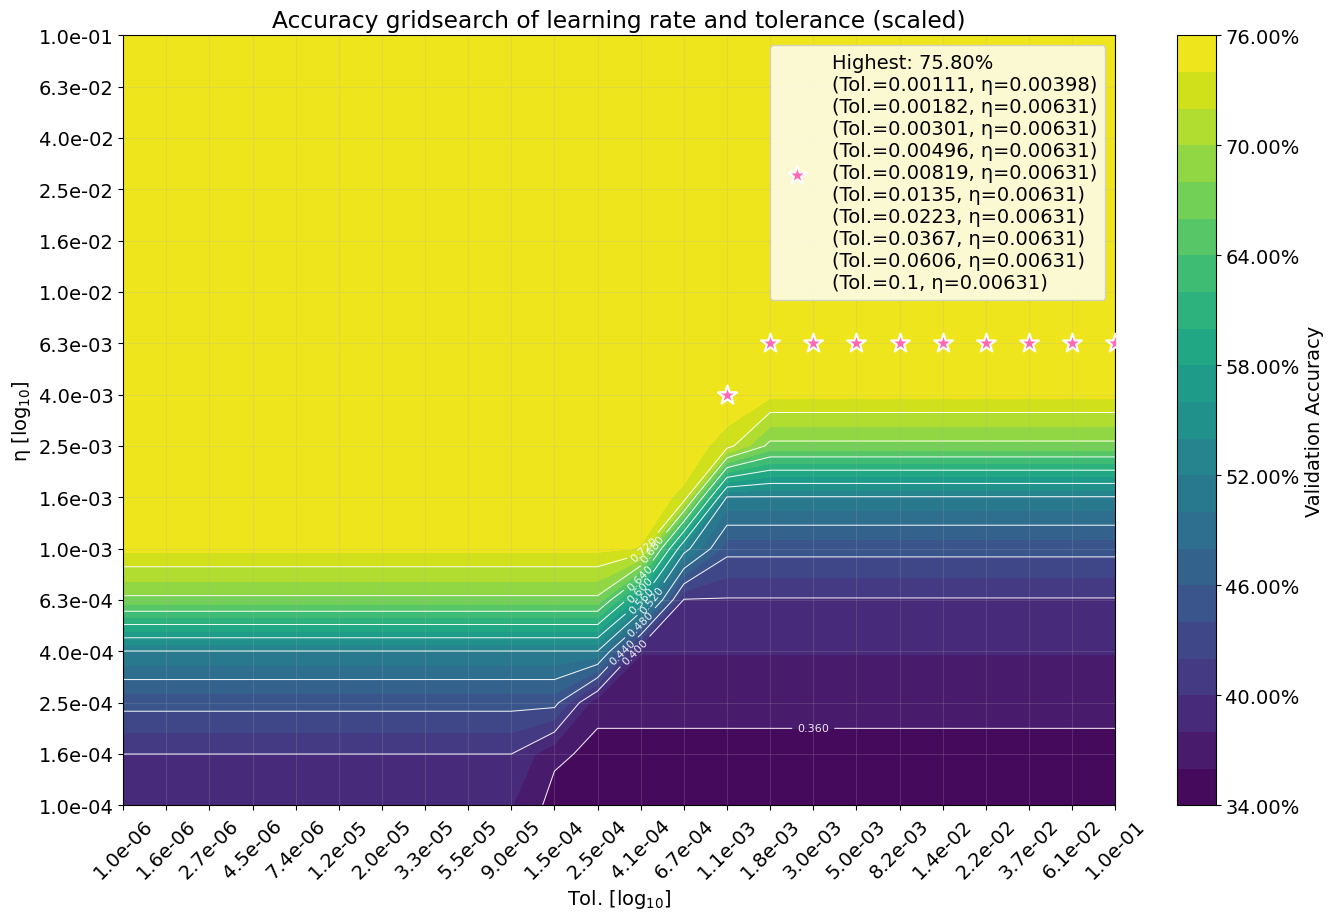

In [69]:
fig = plot_grid_search(accuracies_logreg_scaled, tolerances, learning_rates_logreg, labels=('Tol.', 'η'), logx=True, logy=True)
plt.title('Accuracy gridsearch of learning rate and tolerance (scaled)')
plt.show()

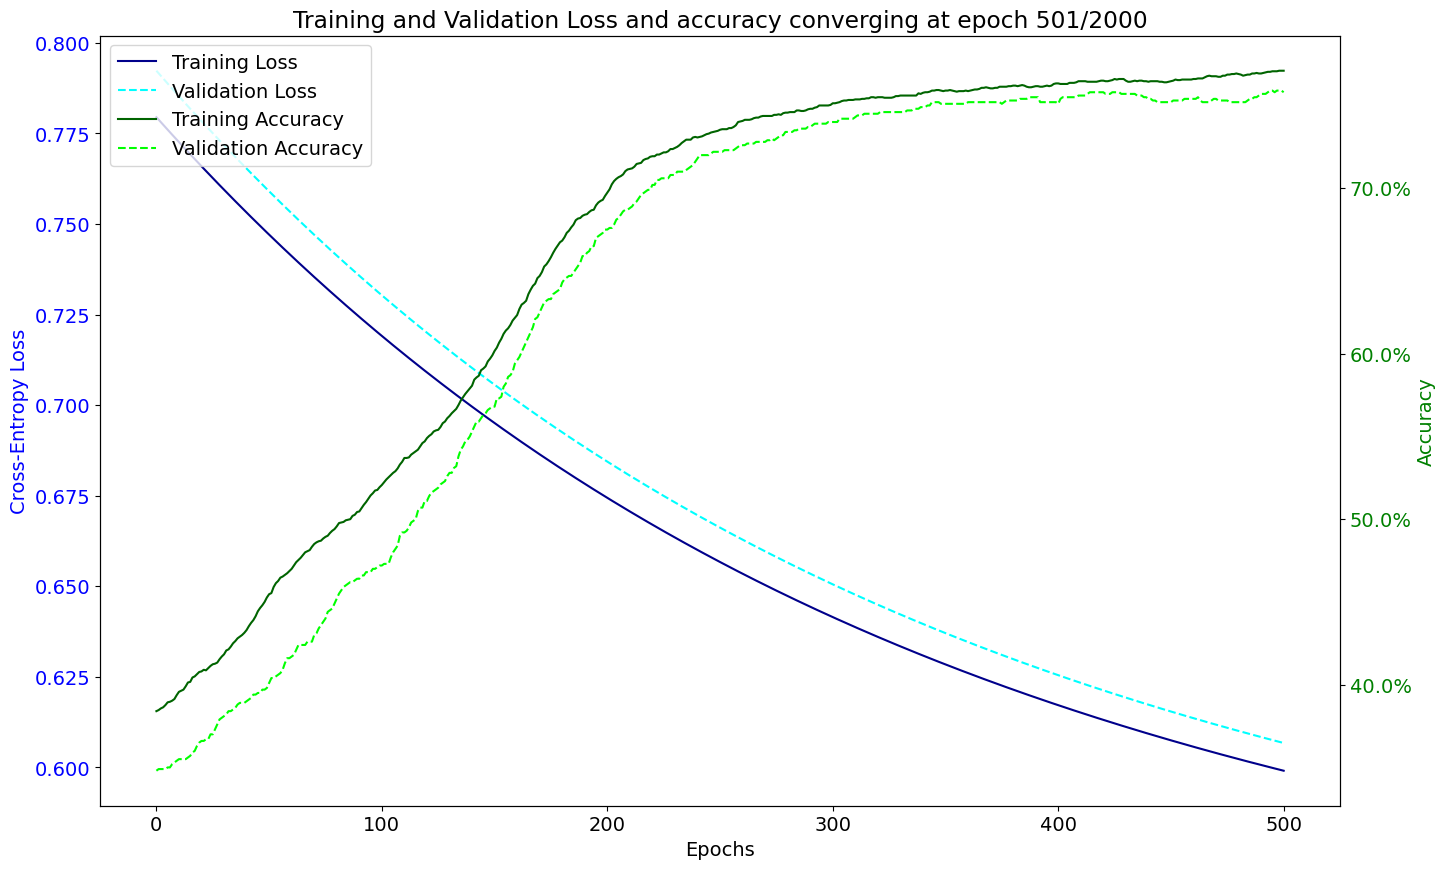

In [70]:
cl_logreg_scaled = NumpyLogReg()
best_accuracy_logreg_scaled, best_tols_logreg_scaled, best_lrs_logreg_scaled = optimal_hyperparameters(accuracies_logreg_scaled, tolerances, learning_rates_logreg)

# Find the best hyperparameters with the highest tolerance
best_tols_logreg_scaled, best_lrs_logreg_scaled = sort_optimal_hyperparameters(best_tols_logreg_scaled, best_lrs_logreg_scaled, descending=True)

n = 6
best_tol_logreg_scaled = best_tols_logreg_scaled[n]
best_lr_logreg_scaled = best_lrs_logreg_scaled[n]

cl_logreg_scaled.fit(X_train_scaled, t2_train, lr=best_lr_logreg_scaled, epochs=epoch, X_val=X_val_scaled, t_val=t2_val, tol=best_tol_logreg_scaled, n_epochs_no_update=n_epochs_no_update, min_epochs=min_epochs)

plot_loss(cl_logreg_scaled, epoch)
plt.show()

## Multi-class classifiers
We turn to the task of classifying when there are more than two classes, and the task is to ascribe one class to each input. We will now use the set `(X, t_multi)`.

### Multi-class with logistic regression
We saw in the lectures how a logistic regression classifier can be turned into a multi-class classifier using the one-vs-rest approach. We train one logistic regression classifier for each class. To predict the class of an item, we run all the binary classifiers and collect the probability score from each of them. We assign the class which ascribes the highest probability.

Build such a classifier. Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Also plot the decision boundaries for your best classifier similarly to the plots for the binary case.

### For IN4050 students: Multinomial logistic regression
The following part is only mandatory for IN4050 students. IN3050 students are also welcome to make it a try. Everybody has to do the part 2 on multi-layer neural networks. 

In the lectures, we contrasted the one-vs-rest approach with the multinomial logistic regression, also called softmax classifier. Implement also this classifier, tune the parameters, and compare the results to the classifiers above. (Don't expect a large difference on a simple task like this.)

Remember that this classifier uses softmax in the forward phase. For loss, it uses categorical cross-entropy loss. The loss has a somewhat simpler form than in the binary case. To calculate the gradient is a little more complicated. The actual gradient and update rule is simple, however, as long as you have calculated the forward values correctly.

Our classifier is not ideal. But is it because all the 10 classes are equally diffucult to predict?
You should evaluate the multinomial model predictions for each class separately and report your findings.
Please also report whether there is any difference in this respect between the training and the validation sets.

# Part 2 Multi-layer neural networks

## A first non-linear classifier

The following code is a simple implementation of a multi-layer perceptron or feed-forward neural network.
For now, it is quite restricted.
There is only one hidden layer with 6 neurons.
It can only handle binary classification.
In addition, it uses a simple final layer similar to the linear regression classifier above.
One way to look at it is what happens when we add a hidden layer to the linear regression classifier.

The MLP class below misses the implementation of the `forward()` function. Your first task is to implement it. 

Remember that in the forward pass, we "feed" the input to the model, the model processes it and produces the output. The function should make use of the logistic activation function and bias.

In [71]:
# First, we define the logistic function and its derivative:
def logistic(x):
    return 1/(1+np.exp(-x))

def logistic_diff(y):
    return y * (1 - y)

In [72]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6):
        """Intialize the hyperparameters"""
        self.bias = bias
        # Dimensionality of the hidden layer
        self.dim_hidden = dim_hidden
        
        self.activ = logistic
        
        self.activ_diff = logistic_diff
        
    def forward(self, X):
        """TODO: 
        Perform one forward step. 
        Return a pair consisting of the outputs of the hidden_layer
        and the outputs on the final layer"""
        
        raise NotImplementedError
        # return hidden_outs, outputs
    
    def fit(self, X_train, t_train, lr=0.001, epochs = 100):
        """Initialize the weights. Train *epochs* many epochs.
        
        X_train is a NxM matrix, N data points, M features
        t_train is a vector of length N of targets values for the training data, 
        where the values are 0 or 1.
        lr is the learning rate
        """
        self.lr = lr
        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        self.weights1 = (np.random.rand(
            dim_in + 1, 
            self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand(
            self.dim_hidden+1, 
            dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        
        for e in range(epochs):
            # One epoch
            # The forward step:
            hidden_outs, outputs = self.forward(X_train_bias)
            # The delta term on the output node:
            out_deltas = (outputs - T_train)
            # The delta terms at the output of the hidden layer:
            hiddenout_diffs = out_deltas @ self.weights2.T
            # The deltas at the input to the hidden layer:
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * 
                                self.activ_diff(hidden_outs[:, 1:]))  

            # Update the weights:
            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas 
            
    
    def predict(self, X):
        """Predict the class for the members of X"""
        Z = add_bias(X, self.bias)
        forw = self.forward(Z)[1]
        score= forw[:, 0]
        return (score > 0.5)

When implemented, this model can be used to make a non-linear classifier for the set `(X, t2)`. Experiment with settings for learning rate and epochs and see how good results you can get. 
Report results for various settings. Be prepared to train for a long time (but you can control it via the number of epochs and hidden size). 

Plot the training set together with the decision regions as in Part I.

# Improving the MLP classifier
You should now make changes to the classifier similarly to what you did with the logistic regression classifier in part 1.

a) In addition to the `predict()` method, which predicts a class for the data, include the `predict_probabilities()` method which predict the probability of the data belonging to the positive class. The training should be based on these values, as with logistic regression.

b) Calculate the loss and the accuracy after each epoch and store them for inspection after training.

c) Extend the `fit()` method with optional arguments for a validation set `(X_val, t_val)`. If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch.

d) Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved for more than `tol` after `n_epochs_no_update`. A possible default value for `n_epochs_no_update` is 2. Add an attribute to the classifier which tells us after fitting how many epochs it was trained on.

e) Tune the hyper-parameters: `lr`, `tol` and `dim-hidden` (size of the hidden layer).
Also, consider the effect of scaling the data.

f) After a succesful training with the best setting for the hyper-parameters, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see.

g) The MLP algorithm contains an element of non-determinism. Hence, train the classifier 3 times with the optimal hyper-parameters and report the mean and standard deviation of the accuracies over the 3 runs.

## For IN4050-students: Multi-class neural network

The following part is only mandatory for IN4050 students. IN3050 students are also welcome to make it a try. This is the most fun part of the set :) )

The goal is to use a feed-forward neural network for non-linear multi-class classfication and apply it to the set `(X, t_multi)`.

Modify the network to become a multi-class multinomial classifier. As a sanity check of your implementation, you may apply it to `(X, t_2)` and see whether you get similar results as above.

Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Plot the decision boundaries for your best classifier. Evaluate the  best model predictions for each class separately (same as in part 1)  and report your findings. Please also report whether there is any difference in this respect between the training and the validation sets.

# Part III: Final testing
We can now perform a final testing on the held-out test set we created in the beginning.

## Binary task (X, t2)
Consider the linear regression classifier, the logistic regression classifier and the multi-layer network with the best settings you found. Train each of them on the training set and evaluate on the held-out test set, but also on the validation set and the training set. Report the performance in a 3 by 3 table.

Comment on what you see. How do the three different algorithms compare? Also, compare the results between the different dataset splits. In cases like these, one might expect slightly inferior results on the held-out test data compared to the validation and training data. Is this the case? 

Also report precision and recall for class 1.

## For IN4050-students: Multi-class task (X, t_multi)

The following part is only mandatory for IN4050-students. IN3050-students are also welcome to give it a try though.

Compare the three multi-class classifiers: the standard multi-class and the multinomial logistic regression from part one and the multi-class neural network from part two. Evaluate on test, validation and training set as above.

Comment on the results.